## Enviornment Setup

In [26]:
!pip install xgboost shap

## Imports

In [27]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score

from xgboost import XGBClassifier
import shap


## Dataset Loading

In [28]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"
df = pd.read_csv(url, sep=" ", header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


## Assigning Proper Columns Name


In [29]:
columns = [
    "Status_Checking_Acc", "Duration", "Credit_History",
    "Purpose", "Credit_Amount", "Savings_Acc",
    "Employment_Since", "Installment_Rate",
    "Personal_Status_Sex", "Other_Debtors",
    "Present_Residence", "Property",
    "Age", "Other_Installment_Plans",
    "Housing", "Num_Existing_Credits",
    "Job", "Num_People_Liable",
    "Telephone", "Foreign_Worker",
    "CreditRisk"
]

df.columns = columns
df.head()

,Status_Checking_Acc,Duration,Credit_History,Purpose,Credit_Amount,Savings_Acc,Employment_Since,Installment_Rate,Personal_Status_Sex,Other_Debtors,...,Property,Age,Other_Installment_Plans,Housing,Num_Existing_Credits,Job,Num_People_Liable,Telephone,Foreign_Worker,CreditRisk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


## Target Variable Cleaning

In [30]:
df["CreditRisk"] = df["CreditRisk"].map({1: 0, 2: 1})

## Feature and Target Split

In [31]:
X = df.drop("CreditRisk", axis=1)
y = df["CreditRisk"]

## Checking for missing values


In [32]:
df.isnull().sum()

,0
Status_Checking_Acc,0
Duration,0
Credit_History,0
Purpose,0
Credit_Amount,0
Savings_Acc,0
Employment_Since,0
Installment_Rate,0
Personal_Status_Sex,0
Other_Debtors,0


## Identifying feature types

In [33]:
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

## Feature/Target Split

In [34]:
# x = df.drop("CreditRisk", axis=1)
# y = df["CreditRisk"]

## Cleaning and Preprocessing

In [35]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(X , y, test_size=0.2, stratify = y,random_state=42)

## Class Imbalance Check

In [36]:
y.value_counts(normalize=True)

,proportion
CreditRisk,
0,0.7
1,0.3


## Train the Interpretable Model


In [37]:
log_reg = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, solver="lbfgs"))
    ]
)

log_reg.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Duration', 'Credit_Amount', 'Installment_Rate', 'Present_Residence',
       'Age', 'Num_Existing_Credits', 'Num_People_Liable'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Status_Checking_Acc', 'Credit_History', 'Purpose', 'Savings_Acc',
       'Employment_Since', 'Personal_Status_Sex', 'Other_Debtors', 'Property',
       'Other_Installment_Plans', 'Housing', 'Job', 'Telephone',
       'Foreign_Worker'],
      dtype='object'))])),
                ('classifier', LogisticRegression(max_iter=1000))])

## Training the High-Accuracy Model

In [38]:
xgb = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("classifier", XGBClassifier(
            n_estimators=100,
            max_depth=3,
            learning_rate=0.1,
            subsample=0.5,
            colsample_bytree=0.5,
            eval_metric="logloss",
            random_state=42
        ))
    ]
)

xgb.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Duration', 'Credit_Amount', 'Installment_Rate', 'Present_Residence',
       'Age', 'Num_Existing_Credits', 'Num_People_Liable'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Status_Checking_Acc', 'Credit_History', 'Purpose', 'Savings_Acc',
       'Employm...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [39]:
# print("LR trained:", log_reg is not None)
# print("XGB trained:", xgb is not None)


LR trained: True
XGB trained: True


## Explainability for Logistic Regression (Borederline Case)

In [42]:
feature_names = (
    numerical_cols.tolist() +
    list(
        log_reg.named_steps["preprocess"]
        .named_transformers_["cat"]
        .get_feature_names_out(categorical_cols)
    )
)

coefficients = log_reg.named_steps["classifier"].coef_[0]

lr_explanations = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
}).sort_values(by="Coefficient", ascending=False)

lr_explanations.head(10)

,Feature,Coefficient
23,Purpose_A46,0.901684
46,Property_A124,0.713710
7,Status_Checking_Acc_A11,0.657834
26,Savings_Acc_A61,0.640212
59,Foreign_Worker_A201,0.567781
50,Housing_A151,0.561244
11,Credit_History_A30,0.540755
16,Purpose_A40,0.516158
22,Purpose_A45,0.442572
36,Personal_Status_Sex_A91,0.437304


## Baseline Model Evaluation (German Credit Dataset)

In [43]:
# Logistic Regression evaluation
lr_accuracy = accuracy_score(y_test, log_reg.predict(X_test))
lr_auc = roc_auc_score(y_test, log_reg.predict_proba(X_test)[:, 1])

# XGBoost evaluation
xgb_accuracy = accuracy_score(y_test, xgb.predict(X_test))
xgb_auc = roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1])

print("=== Baseline Models Performance ===")
print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")
print(f"Logistic Regression ROC-AUC: {lr_auc:.4f}")
print(f"XGBoost Accuracy: {xgb_accuracy:.4f}")
print(f"XGBoost ROC-AUC: {xgb_auc:.4f}")

=== Baseline Models Performance ===
Logistic Regression Accuracy: 0.7800
Logistic Regression ROC-AUC: 0.8040
XGBoost Accuracy: 0.7700
XGBoost ROC-AUC: 0.8162


## Confidence-Aware Dual-Model Framework

### Confidence Thresholds

Predictions are categorized as follows:
- High confidence: probability ≤ 0.3 or ≥ 0.7
- Borderline (uncertain): probability between 0.3 and 0.7

Borderline cases are routed to the interpretable model for transparent decision-making.

In [44]:
LOW_THRESHOLD = 0.3
HIGH_THRESHOLD = 0.7


## Framework Inference on Test Data

In [45]:
results = []

for i in range(len(X_test)):
    x = X_test.iloc[[i]]
    prob_xgb = xgb.predict_proba(x)[0][1]

    if prob_xgb <= LOW_THRESHOLD or prob_xgb >= HIGH_THRESHOLD:
        probability = prob_xgb
        prediction = int(probability >= 0.5)
        model_used = "XGBoost"
    else:
        probability = log_reg.predict_proba(x)[0][1]
        prediction = int(probability >= 0.5)
        model_used = "LogisticRegression"

    results.append({
        "probability": probability,
        "prediction": prediction,
        "model_used": model_used
    })

results_df = pd.DataFrame(results)
results_df.head()


,probability,prediction,model_used
0,0.226808,0,LogisticRegression
1,0.133354,0,XGBoost
2,0.618768,1,LogisticRegression
3,0.493357,0,LogisticRegression
4,0.127538,0,XGBoost


## Framework Performance Evaluation

In [46]:
framework_accuracy = accuracy_score(y_test, results_df["prediction"])
framework_auc = roc_auc_score(y_test, results_df["probability"])
interpretability_coverage = (
    results_df["model_used"] == "LogisticRegression"
).mean()

print("=== Confidence-Aware Framework Performance ===")
print(f"Framework Accuracy: {framework_accuracy:.4f}")
print(f"Framework ROC-AUC: {framework_auc:.4f}")
print(f"Interpretability Coverage: {interpretability_coverage:.4f}")


=== Confidence-Aware Framework Performance ===
Framework Accuracy: 0.7800
Framework ROC-AUC: 0.8258
Interpretability Coverage: 0.3400


## Logistic Regression Explainability

In [47]:
# Extract feature names after preprocessing
num_features = numerical_cols.tolist()
cat_features = (
    log_reg.named_steps["preprocess"]
    .named_transformers_["cat"]
    .get_feature_names_out(categorical_cols)
    .tolist()
)

feature_names = num_features + cat_features
coefficients = log_reg.named_steps["classifier"].coef_[0]

lr_explanations = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Odds_Ratio": np.exp(coefficients)
})

lr_explanations["Abs_Coefficient"] = lr_explanations["Coefficient"].abs()
lr_explanations = lr_explanations.sort_values(
    by="Abs_Coefficient", ascending=False
)

lr_explanations.head(10)

,Feature,Coefficient,Odds_Ratio,Abs_Coefficient
23,Purpose_A46,0.901684,2.463749,0.901684
10,Status_Checking_Acc_A14,-0.887112,0.411844,0.887112
15,Credit_History_A34,-0.800579,0.449069,0.800579
17,Purpose_A41,-0.714820,0.489280,0.714820
46,Property_A124,0.713710,2.041551,0.713710
7,Status_Checking_Acc_A11,0.657834,1.930606,0.657834
26,Savings_Acc_A61,0.640212,1.896882,0.640212
29,Savings_Acc_A64,-0.628173,0.533566,0.628173
52,Housing_A153,-0.611037,0.542788,0.611037
60,Foreign_Worker_A202,-0.581531,0.559042,0.581531


## XGBoost Explainability Using SHAP

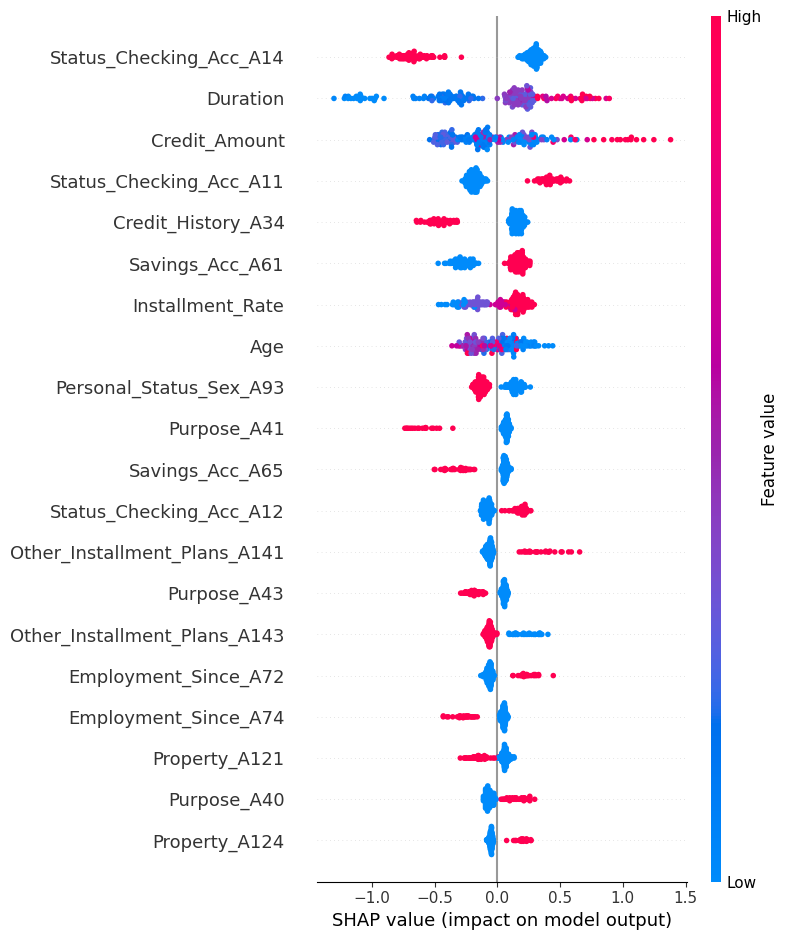

In [48]:

X_train_transformed = xgb.named_steps["preprocess"].transform(X_train)
X_test_transformed = xgb.named_steps["preprocess"].transform(X_test)

explainer = shap.TreeExplainer(xgb.named_steps["classifier"])
shap_values = explainer.shap_values(X_test_transformed)

shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    show=False
)
